In [5]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.models import MobileNet_V2_Weights
from PIL import Image
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from collections import Counter

In [6]:
DATA_ROOT = Path("../datasets/kaggle_full")
TRAIN_DIR = DATA_ROOT / "train"
TEST_DIR  = DATA_ROOT / "test"

SEAL_CLASSES = ["bird", "boar", "dog", "dragon", "hare", "horse",
                "monkey", "ox", "ram", "rat", "snake", "tiger"]
CLASS_TO_IDX = {cls: i for i, cls in enumerate(SEAL_CLASSES)}

# MPS for Apple Silicon
DEVICE     = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
# CUDA for NVIDIA GPUs
# DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 64
EPOCHS     = 32
LR         = 5e-4    # initial LR for head
LR_BACKBONE= 1e-5    # lower LR when we unfreeze backbone
PATIENCE = 5
MIN_DELTA = 0.001

print(f"Using device: {DEVICE}")

Using device: mps


## Dataset prep

We can play around with these numbers

In [7]:
# Stronger augmentation for train, clean transforms for test
train_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomCrop(112),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

test_transforms = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

class HandSealDataset(Dataset):
    def __init__(self, split_dir: Path, transform):
        self.samples = []
        self.transform = transform
        for cls in SEAL_CLASSES:
            cls_dir = split_dir / cls
            if not cls_dir.is_dir():   # ← skips .DS_Store
                continue
            for ext in ["*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG"]:
                for img_path in cls_dir.glob(ext):
                    self.samples.append((img_path, CLASS_TO_IDX[cls]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        return self.transform(img), label

## Dataloader

In [8]:
# Debug cell — run this to see what's actually in your dataset folder
print(f"DATA_ROOT exists: {DATA_ROOT.exists()}")
print(f"TRAIN_DIR exists: {TRAIN_DIR.exists()}")
print()

# Show actual folder names
print("Actual folders in TRAIN_DIR:")
for f in sorted(TRAIN_DIR.iterdir()):
    print(f"  '{f.name}'")

print()

# Show actual file extensions
sample_class = next(f for f in TRAIN_DIR.iterdir() if f.is_dir())
print(f"Sample files in '{sample_class.name}':")
for f in list(sample_class.iterdir())[:5]:
    print(f"  '{f.name}'  (suffix: '{f.suffix}')")

DATA_ROOT exists: True
TRAIN_DIR exists: True

Actual folders in TRAIN_DIR:
  '.DS_Store'
  'bird'
  'boar'
  'dog'
  'dragon'
  'hare'
  'horse'
  'monkey'
  'ox'
  'ram'
  'rat'
  'snake'
  'tiger'
  'zero'

Sample files in 'dog':
  'dog_IMG_0254c2ba4-4a9c-11ea-843c-0242ac1c0002.jpg'  (suffix: '.jpg')
  'IMG_e84439c9-547b-11ea-97a8-48f17fc25591.png'  (suffix: '.png')
  'IMG_e84dd026-547b-11ea-8e6d-48f17fc25591.png'  (suffix: '.png')
  'dog_49_jpg.rf.978b06a101055ffc48d37ac45fdca86b.jpg'  (suffix: '.jpg')
  'IMG_e84807be-547b-11ea-a8d9-48f17fc25591.png'  (suffix: '.png')


Train: 2920 images
Test:  321 images


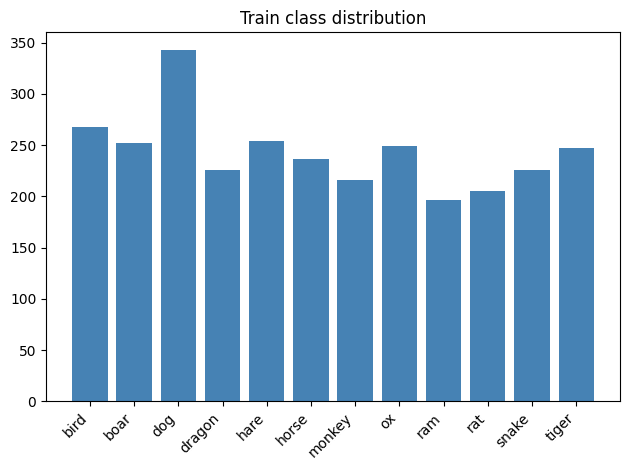

In [9]:
train_dataset = HandSealDataset(TRAIN_DIR, train_transforms)
test_dataset  = HandSealDataset(TEST_DIR,  test_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0, pin_memory=False)

print(f"Train: {len(train_dataset)} images")
print(f"Test:  {len(test_dataset)} images")

# Class balance check
counts = Counter(label for _, label in train_dataset.samples)
plt.bar(SEAL_CLASSES, [counts[CLASS_TO_IDX[c]] for c in SEAL_CLASSES], color="steelblue")
plt.xticks(rotation=45, ha="right")
plt.title("Train class distribution")
plt.tight_layout()
plt.show()

## Model

frozen Backbone, trainable head

In [10]:
def build_model(num_classes: int = 12) -> nn.Module:
    model = models.mobilenet_v2(weights=MobileNet_V2_Weights.DEFAULT)

    # Freeze all backbone layers
    for p in model.features.parameters():
        p.requires_grad = False

    # Replace classifier head
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.5),
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(p=0.4),
        nn.Linear(256, num_classes)
    )
    return model

model = build_model(num_classes=12).to(DEVICE)

# Count trainable params
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable: {trainable:,} / {total:,} params")

Trainable: 331,020 / 2,554,892 params


In [11]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct = 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(imgs)
        correct += (logits.argmax(1) == labels).sum().item()
    return total_loss / len(loader.dataset), correct / len(loader.dataset)

@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct = 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        logits = model(imgs)
        total_loss += criterion(logits, labels).item() * len(imgs)
        correct += (logits.argmax(1) == labels).sum().item()
    return total_loss / len(loader.dataset), correct / len(loader.dataset)

## Phase 1

Train head only

In [13]:
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()), lr=LR
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=8   # matches your epoch count exactly
)

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

print("Phase 1: Training head only")
for epoch in range(8):
    model.train()
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(imgs), labels)
        loss.backward()
        optimizer.step()

    scheduler.step()   # ← back to per epoch, not per batch

    tr_loss, tr_acc = eval_epoch(model, train_loader, criterion)
    va_loss, va_acc = eval_epoch(model, test_loader,  criterion)

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(va_loss)
    history["val_acc"].append(va_acc)

    print(f"Epoch {epoch+1:02d} | "
          f"train loss {tr_loss:.3f} acc {tr_acc:.3f} | "
          f"val loss {va_loss:.3f} acc {va_acc:.3f}")

Phase 1: Training head only
Epoch 01 | train loss 1.548 acc 0.660 | val loss 1.916 acc 0.424
Epoch 02 | train loss 1.155 acc 0.734 | val loss 1.673 acc 0.508
Epoch 03 | train loss 0.965 acc 0.785 | val loss 1.549 acc 0.520
Epoch 04 | train loss 0.833 acc 0.799 | val loss 1.471 acc 0.539
Epoch 05 | train loss 0.802 acc 0.801 | val loss 1.393 acc 0.576
Epoch 06 | train loss 0.769 acc 0.817 | val loss 1.362 acc 0.583
Epoch 07 | train loss 0.767 acc 0.812 | val loss 1.352 acc 0.589
Epoch 08 | train loss 0.744 acc 0.826 | val loss 1.356 acc 0.586


## Phase 2: Train frozen backbone

In [14]:
best_val_acc  = 0
patience_counter = 0

for epoch in range(25):
    tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion)
    va_loss, va_acc = eval_epoch(model, test_loader,  criterion)
    scheduler.step()

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(va_loss)
    history["val_acc"].append(va_acc)

    improved = va_acc > best_val_acc + MIN_DELTA
    if improved:
        best_val_acc     = va_acc
        patience_counter = 0
        torch.save(model.state_dict(), "mobilenetv2_best.pth")
    else:
        patience_counter += 1

    print(f"Epoch {epoch+11:02d} | "
          f"train loss {tr_loss:.3f} acc {tr_acc:.3f} | "
          f"val loss {va_loss:.3f} acc {va_acc:.3f}"
          + (" ← best" if improved else f" (patience {patience_counter}/{PATIENCE})"))

    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch+11}")
        break

print(f"\nBest val accuracy: {best_val_acc:.3f}")

Epoch 11 | train loss 0.940 acc 0.726 | val loss 1.338 acc 0.583 ← best
Epoch 12 | train loss 0.951 acc 0.715 | val loss 1.363 acc 0.570 (patience 1/5)
Epoch 13 | train loss 0.947 acc 0.724 | val loss 1.338 acc 0.583 (patience 2/5)
Epoch 14 | train loss 0.945 acc 0.719 | val loss 1.316 acc 0.589 ← best
Epoch 15 | train loss 0.921 acc 0.723 | val loss 1.293 acc 0.589 (patience 1/5)
Epoch 16 | train loss 0.898 acc 0.730 | val loss 1.283 acc 0.592 ← best
Epoch 17 | train loss 0.887 acc 0.723 | val loss 1.267 acc 0.601 ← best
Epoch 18 | train loss 0.849 acc 0.725 | val loss 1.227 acc 0.604 ← best
Epoch 19 | train loss 0.834 acc 0.747 | val loss 1.226 acc 0.589 (patience 1/5)
Epoch 20 | train loss 0.811 acc 0.752 | val loss 1.220 acc 0.579 (patience 2/5)
Epoch 21 | train loss 0.815 acc 0.749 | val loss 1.219 acc 0.592 (patience 3/5)
Epoch 22 | train loss 0.774 acc 0.760 | val loss 1.199 acc 0.614 ← best
Epoch 23 | train loss 0.746 acc 0.761 | val loss 1.198 acc 0.614 (patience 1/5)
Epoch 24

## Analysis

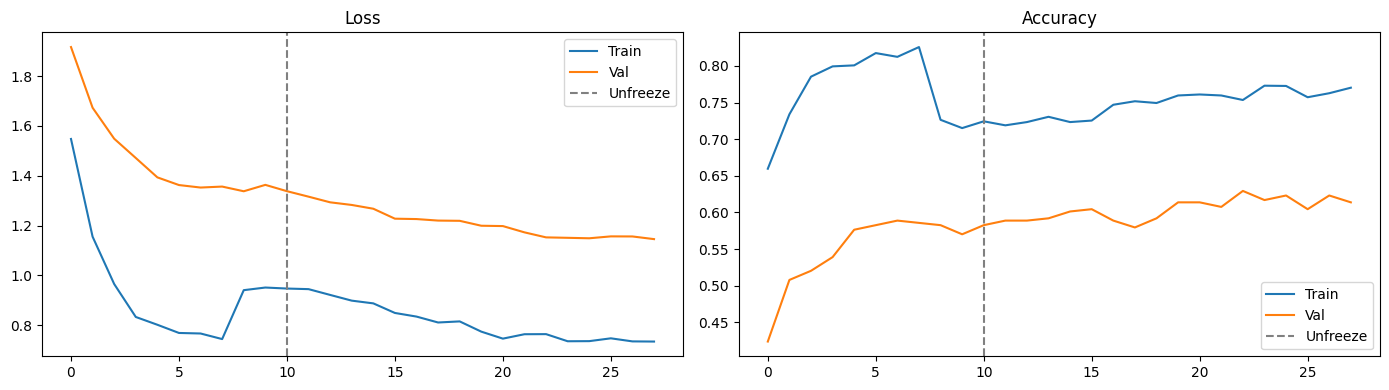

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(history["train_loss"], label="Train")
ax1.plot(history["val_loss"],   label="Val")
ax1.axvline(10, color="gray", linestyle="--", label="Unfreeze")
ax1.set_title("Loss"); ax1.legend()

ax2.plot(history["train_acc"], label="Train")
ax2.plot(history["val_acc"],   label="Val")
ax2.axvline(10, color="gray", linestyle="--", label="Unfreeze")
ax2.set_title("Accuracy"); ax2.legend()

plt.tight_layout()
plt.show()

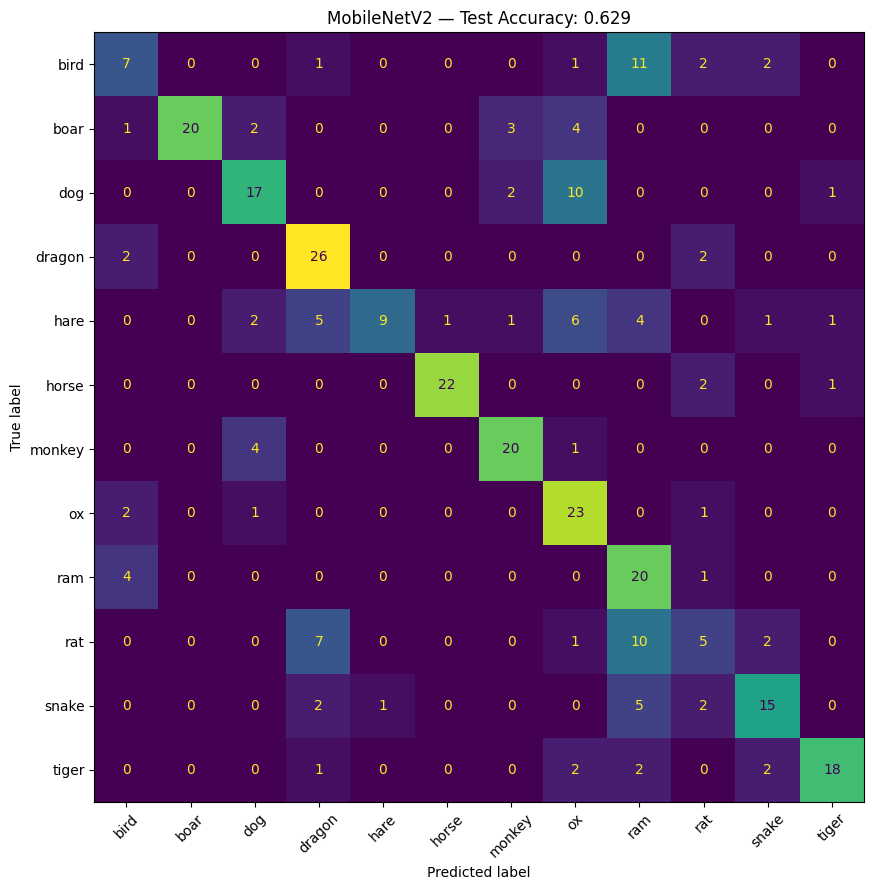

In [16]:
model.load_state_dict(torch.load("mobilenetv2_best.pth", map_location=DEVICE))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        preds = model(imgs.to(DEVICE)).argmax(1).cpu()
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=SEAL_CLASSES)

fig, ax = plt.subplots(figsize=(11, 9))
disp.plot(ax=ax, colorbar=False, xticks_rotation=45)
plt.title(f"MobileNetV2 — Test Accuracy: {accuracy_score(all_labels, all_preds):.3f}")
plt.tight_layout()
plt.show()

In [17]:
model.eval()
top3_correct = 0
with torch.no_grad():
    for imgs, labels in test_loader:
        logits = model(imgs.to(DEVICE))
        top3 = logits.topk(3, dim=1).indices.cpu()
        for pred_top3, label in zip(top3, labels):
            if label in pred_top3:
                top3_correct += 1

print(f"Top-1 accuracy: {accuracy_score(all_labels, all_preds):.3f}")
print(f"Top-3 accuracy: {top3_correct / len(test_dataset):.3f}")

Top-1 accuracy: 0.629
Top-3 accuracy: 0.860


## Live feed test

In [18]:
JUTSU_COMBOS = {
    # Fire Style
    ("Snake", "Ram", "Monkey", "Boar", "Horse", "Tiger"): "Fire Style: Fireball Jutsu",
    ("Ox", "Snake", "Dog", "Tiger"):                       "Fire Style: Dragon Flame Jutsu",
    ("Rat", "Tiger", "Dog", "Ox", "Ram", "Monkey"):        "Fire Style: Phoenix Flower Jutsu",

    # Water Style
    ("Ox", "Monkey", "Rat", "Ram", "Snake", "Dragon"):     "Water Style: Hidden Mist Jutsu",
    ("Tiger", "Ox", "Monkey", "Hare", "Ox"):             "Water Style: Water Prison Jutsu",

    # Lightning Style
    ("Ox", "Hare", "Monkey"):                            "Lightning Style: Chidori",

    # Wind Style
    ("Tiger", "Ox", "Dog", "Hare", "Bird"):              "Wind Style: Great Breakthrough",

    # Earth Style
    ("Tiger", "Hare", "Boar", "Dog"):                    "Earth Style: Earth Wall",
    ("Tiger", "Hare", "Snake"):                          "Earth Style: Rock Pillar Spears",

    # General Ninjutsu
    ("Ram", "Snake", "Tiger"):                             "Shadow Clone Jutsu",
    ("Boar", "Dog", "Bird", "Monkey", "Ram"):              "Summoning Jutsu",
    ("Tiger", "Snake", "Dog", "Dragon"):                   "Reanimation Jutsu",
    ("Dog", "Dragon", "Bird"):                             "Transformation Jutsu",
}


In [ ]:
import cv2
import torch
import torch.nn.functional as F
from torchvision import transforms
from collections import deque

# Load best checkpoint
model.load_state_dict(torch.load("mobilenetv2_best.pth", map_location=DEVICE))
model.eval()

# Use same transforms as test (no augmentation)
infer_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((112, 112)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

CONFIDENCE_THRESHOLD = 0.6   # only show prediction if model is confident enough
SMOOTHING_WINDOW     = 10    # majority vote over last N frames

frame_preds = deque(maxlen=SMOOTHING_WINDOW)
cap = cv2.VideoCapture(1)

print("Press Q to quit")

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Inference
    rgb    = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    tensor = infer_transforms(rgb).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        logits = model(tensor)
        probs  = F.softmax(logits, dim=1)
        conf, pred_idx = probs.max(dim=1)
        conf      = conf.item()
        pred_idx  = pred_idx.item()

    # Smooth predictions over last N frames
    if conf >= CONFIDENCE_THRESHOLD:
        frame_preds.append(pred_idx)

    if frame_preds:
        smoothed_idx  = Counter(frame_preds).most_common(1)[0][0]
        smoothed_label = SEAL_CLASSES[smoothed_idx]
    else:
        smoothed_label = "..."

    # Check for jutsu combo
    seal_sequence = [SEAL_CLASSES[i] for i in frame_preds]
    jutsu_label   = None
    for combo, name in JUTSU_COMBOS.items():
        if len(seal_sequence) >= len(combo):
            if tuple(seal_sequence[-len(combo):]) == combo:
                jutsu_label = name

    # Overlay
    display = jutsu_label if jutsu_label else smoothed_label
    color   = (0, 255, 100) if jutsu_label else (0, 200, 255)

    cv2.putText(frame, display,          (20, 55),
                cv2.FONT_HERSHEY_SIMPLEX, 1.4, color, 3)
    cv2.putText(frame, f"conf: {conf:.2f}", (20, 95),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (200, 200, 200), 2)

    cv2.imshow("Naruto Handsign — MobileNetV2", frame)
    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()

Press Q to quit


: 